# Neural network classifier

___

## Data onboarding and preprocessing

### Load data

In [21]:
import os 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from numpy.typing import NDArray
from sklearn.decomposition import PCA
from sklearn.model_selection import StratifiedKFold
from typing import List, Optional, Callable 
import pickle
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

# Import custom neural network implementation
from neural_network import *

np.random.seed(42)

dir_path = "../training_data"

names, labels, samples = [], [], []
for label in range(10): 
    for file_path in [os.path.join(dir_path, f) for f in os.listdir(dir_path) if ".csv" in f and f"stroke_{label}" in f]: 
        names.append(os.path.splitext(os.path.basename(file_path))[0])
        labels.append(label)
        samples.append(pd.read_csv(file_path, header=None))

### Preprocess the data

Preprocess the samples and convert labels to numpy array

In [22]:
from NN_preprocessing import *

# Define interpolation target length and image size
target_len = 256 # max([len(s) for s in samples])

# Preprocess samples
# Parameters: sample, use_interpolation, use_PCA, use_convert_to_image, use_flatten, target_len, img_size
# X = np.array([preprocess(s, True, False, False, True, target_len, img_size) for s in samples])

#X_scaled = []
# for x in X: 
#     x_scaled = (x - np.mean(x, axis=0)) / np.max(np.abs(x)) 
#     X_scaled.append(x_scaled)
#X = [StandardScaler().fit_transform(np.array(s)) for s in X_scaled]

X = [s.to_numpy() if isinstance(s, pd.DataFrame) else s for s in samples ]
#X = [project_to_2d(x, True, True) for x in X]
X = [resample(np.array(s), target_len) for s in X]
X = [x.flatten() for x in X]
X = [min_max_scale(x) for x in X]
X = np.array(X)
print(X.shape)

(1000, 768)


One hot encode y: 

In [23]:
# Convert labels to a numpy array
y = np.array(labels)

___

## Training the model 

### Train the model 

In [24]:
uniform = np.random.uniform

# Training parameters
batch_size, learning_rate, weight_decay = 16, 0.005, 0.0001
epochs, tolerance, min_loss = 10, 0, 0.001
criterion = CategoricalCrossEntropySoftmax()
n_splits = 5 # Number of splits for k-fold cross-validation

# Prepare a list for results
results = []

# One-hot encode y
y_encoded = one_hot_encode(y, np.arange(10))

# Train the model using k-fold cross-validation
kf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
for i, (train_idx, test_idx) in enumerate(kf.split(X, y)):

    # Split the data to training and test sets
    X_train, X_test, y_train, y_test = X[train_idx], X[test_idx], y_encoded[train_idx], y_encoded[test_idx]

    # Initialize a new model 
    model = NeuralNetworkClassifier(
        Dense(uniform(-0.1, 0.1, size=(X.shape[1], 512)), np.zeros(512), ReLU),
        Dense(uniform(-0.1, 0.1, size=(512, 512)), np.zeros(512), ReLU),
        Dense(uniform(-0.1, 0.1, size=(512, 512)), np.zeros(512), ReLU),
        Dense(uniform(-0.1, 0.1, size=(512, 512)), np.zeros(512), ReLU),
        Dense(uniform(-0.1, 0.1, size=(512, 10)), np.zeros(10), Softmax)
    )
    
    # Train the model  
    loss_history, accuracy_history = train(model, X_train, y_train, 
        X_val=X_test, y_val=y_test, criterion=criterion, 
        batch_size=batch_size, learning_rate=learning_rate, decay=weight_decay, 
        max_iter=epochs, tol=tolerance, min_loss=min_loss, verbose=True
    )

    # Measure accuracy on the training set
    y_pred = model.forward(X_train)
    accuracy_train = accuracy_score(np.argmax(y_train, axis=1), np.argmax(y_pred, axis=1))

    # Measure accuracy on the test set
    y_pred = model.forward(X_test)
    accuracy_test = accuracy_score(np.argmax(y_test, axis=1), np.argmax(y_pred, axis=1))

    # Measure accuracy on the complete dataset
    y_pred = model.forward(X)
    accuracy_all = accuracy_score(np.argmax(y_encoded, axis=1), np.argmax(y_pred, axis=1))

    # Record results
    results.append({
        "loss_history":loss_history,
        "accuracy_history":accuracy_history,
        "accuracy_train":accuracy_train,
        "accuracy_test":accuracy_test,
        "accuracy_all":accuracy_all,
        "model": model, 
        "train_idx": train_idx,
        "test_idx": test_idx
    })

100%|██████████| 10/10 [00:03<00:00,  2.82it/s]


Generate a unique signature for the model to store results

In [44]:
from datetime import datetime

# Determine model signature (to store results)
nickname = "deeplearning"
dt = datetime.now()
acc = round(np.mean([r["accuracy_test"] for r in results])*100)
num_params = sum([layer.weights.size + layer.biases.size for layer in model.layers])
model_signature = f"d{len(model.layers)}_p{num_params}_e{epochs}_{acc}_{dt.strftime("%Y%m%d")}"
if nickname: model_signature += f"_{nickname}"
print(model_signature)

# Create a new directory for model results
results_dir = os.path.join("results", model_signature)
figs_dir = os.path.join(results_dir, "figures")
model_dir = os.path.join(results_dir, "model")
others_dir = os.path.join(results_dir, "others")
if not os.path.exists(results_dir): os.mkdir(results_dir)
if not os.path.exists(figs_dir): os.mkdir(figs_dir)
if not os.path.exists(model_dir): os.mkdir(model_dir)
if not os.path.exists(others_dir): os.mkdir(others_dir)

d5_p1186826_e10_48_20251202_deeplearning


Visualize results

Fold (1): model accuracy; training set: 56.50 %, test set: 55.50 %, complete set: 56.30 %
Fold (2): model accuracy; training set: 53.62 %, test set: 54.00 %, complete set: 53.70 %
Fold (3): model accuracy; training set: 44.00 %, test set: 41.50 %, complete set: 43.50 %
Fold (4): model accuracy; training set: 40.50 %, test set: 37.00 %, complete set: 39.80 %
Fold (5): model accuracy; training set: 53.37 %, test set: 52.50 %, complete set: 53.20 %
Mean model accuracy; training set: 49.60 %, test set: 48.10 %, complete set: 49.30 %


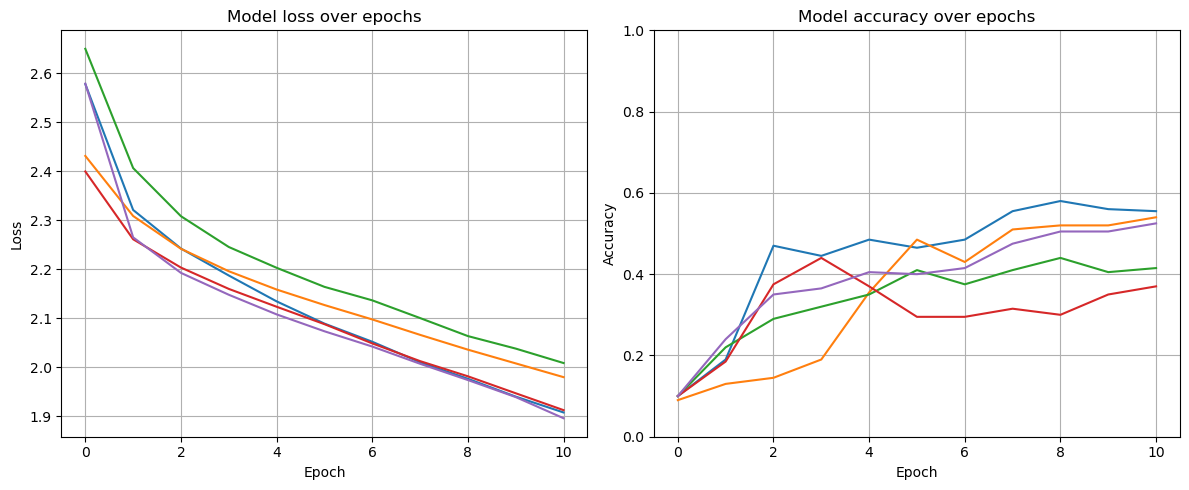

In [26]:
# Visualize training and validation loss
plt.figure(figsize=(12, 5))
for i, result in enumerate(results, 1): 

    loss_history = result["loss_history"]
    accuracy_history = result["accuracy_history"]
    accuracy_train = result["accuracy_train"]
    accuracy_test = result["accuracy_test"]
    accuracy_all = result["accuracy_all"]

    # Visualize training loss
    plt.subplot(1, 2, 1)
    plt.plot(loss_history)
    plt.title("Model loss over epochs")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.grid()

    # Visualize validation accuracy
    ax = plt.subplot(1, 2, 2)
    ax.set_ylim([0, 1])
    plt.grid()
    plt.plot(accuracy_history)
    plt.title("Model accuracy over epochs")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")

    # Measured final accuracy
    print(f"Fold ({i}): model accuracy; training set: {accuracy_train*100:.2f} %", 
          f"test set: {accuracy_test*100:.2f} %",
          f"complete set: {accuracy_all*100:.2f} %", sep=", "
    )

plt.tight_layout()
plt.savefig(os.path.join(figs_dir, f"NN_training_eval_kfold_{model_signature}.png"))

# Calculate combined statistics
mean_train_accuracy = np.mean([r["accuracy_train"] for r in results])
mean_test_accuracy = np.mean([r["accuracy_test"] for r in results])
mean_accuracy_all = np.mean([r["accuracy_all"] for r in results])
print(f"Mean model accuracy; training set: {mean_train_accuracy*100:.2f} %", 
      f"test set: {mean_test_accuracy*100:.2f} %", 
      f"complete set: {mean_accuracy_all*100:.2f} %", sep=", "
)

plt.show()

#### Choose and visualize the best model 

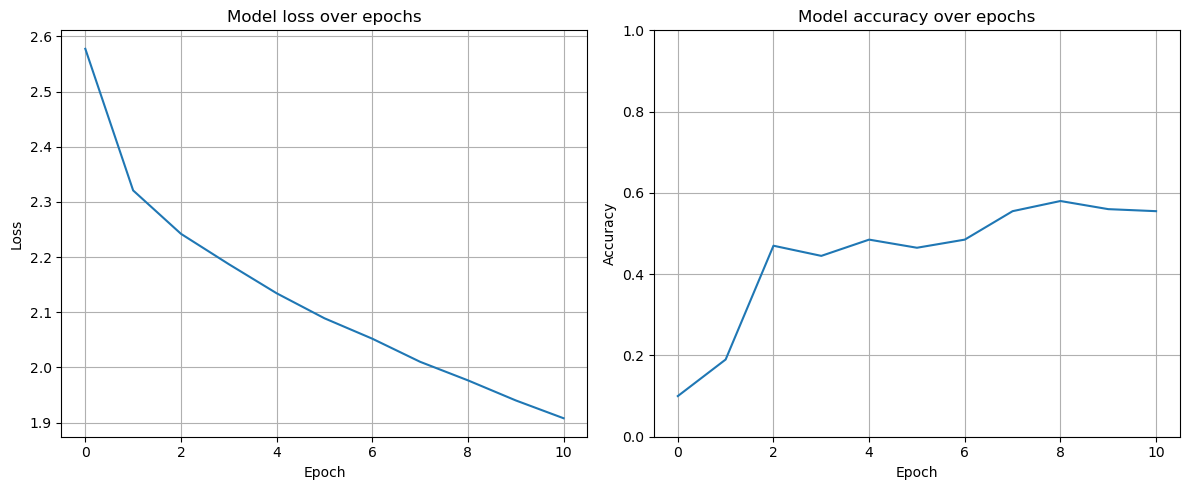

Model accuracy. Training set: 56.50 %, test set: 55.50 %


In [27]:
# Choose the best model 
best_result = results[np.argmin(r['accuracy_test'] for r in results)]
loss_history = best_result["loss_history"]
accuracy_history = best_result["accuracy_history"]
accuracy_train = best_result["accuracy_train"]
accuracy_test = best_result["accuracy_test"]
model = best_result['model']
train_idx, test_idx = best_result['train_idx'], best_result['test_idx']

# Visualize training and validation loss
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(loss_history)
plt.title("Model loss over epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid()

# Visualize validation accuracy
ax = plt.subplot(1, 2, 2)
ax.set_ylim([0, 1])
plt.grid()
plt.plot(accuracy_history)
plt.title("Model accuracy over epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.tight_layout()
plt.savefig(os.path.join(figs_dir, f"NN_training_eval_{model_signature}.png"))
plt.show()

# Measured accuracy
print(f"Model accuracy. Training set: {accuracy_train*100:.2f} %, test set: {accuracy_test*100:.2f} %")

Visualize model performance using a confusion matrix

55.50000000000001 %


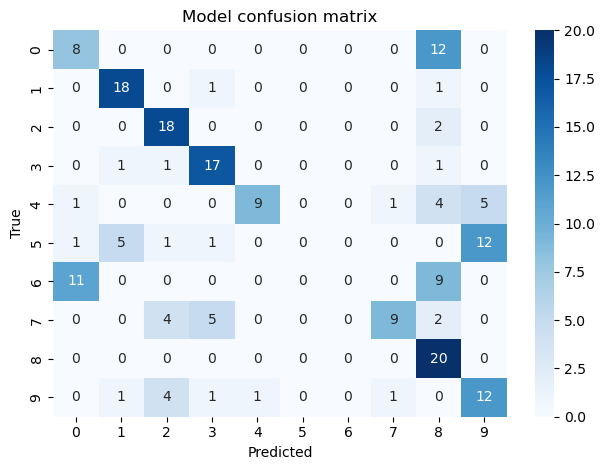

In [28]:
X_test, y_test = X[test_idx], y[test_idx]
y_pred = model.predict(X_test)
print(accuracy_score(y_test, y_pred)*100, "%")

confusion_matrix = np.zeros((10, 10), dtype=int)

for i, j in zip(y_test, y_pred): 
    confusion_matrix[i, j] += 1

sns.heatmap(confusion_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=np.arange(10), yticklabels=np.arange(10))
plt.title("Model confusion matrix")
plt.xlabel("Predicted")
plt.ylabel("True")

plt.tight_layout()
plt.savefig(os.path.join(figs_dir, f"NN_confusion_matrix_{model_signature}.png"))
plt.show()

In [29]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.38      0.40      0.39        20
           1       0.72      0.90      0.80        20
           2       0.64      0.90      0.75        20
           3       0.68      0.85      0.76        20
           4       0.90      0.45      0.60        20
           5       0.00      0.00      0.00        20
           6       0.00      0.00      0.00        20
           7       0.82      0.45      0.58        20
           8       0.39      1.00      0.56        20
           9       0.41      0.60      0.49        20

    accuracy                           0.56       200
   macro avg       0.49      0.55      0.49       200
weighted avg       0.49      0.56      0.49       200



/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


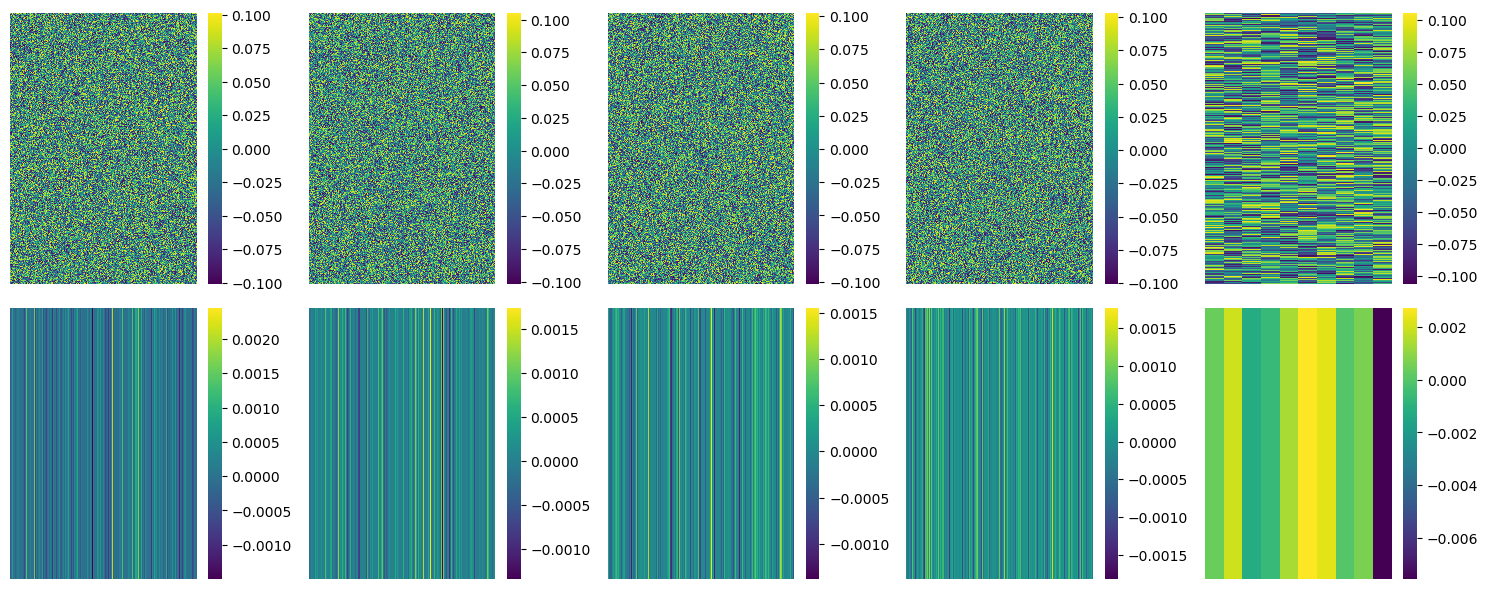

In [30]:
fig, axes = plt.subplots(2, len(model.layers), figsize=(3 * len(model.layers), 6))

for i, layer in enumerate(model.layers):

    sns.heatmap(
        layer.weights,
        cmap="viridis", 
        ax=axes[0, i], 
        annot=False,
    )
    axes[0, i].set_xticks([])
    axes[0, i].set_yticks([])

    sns.heatmap(
        layer.biases.reshape(1, -1),
        cmap="viridis", 
        ax=axes[1, i], 
        annot=False, 
    )
    axes[1, i].set_xticks([])
    axes[1, i].set_yticks([])

plt.tight_layout()
plt.show()

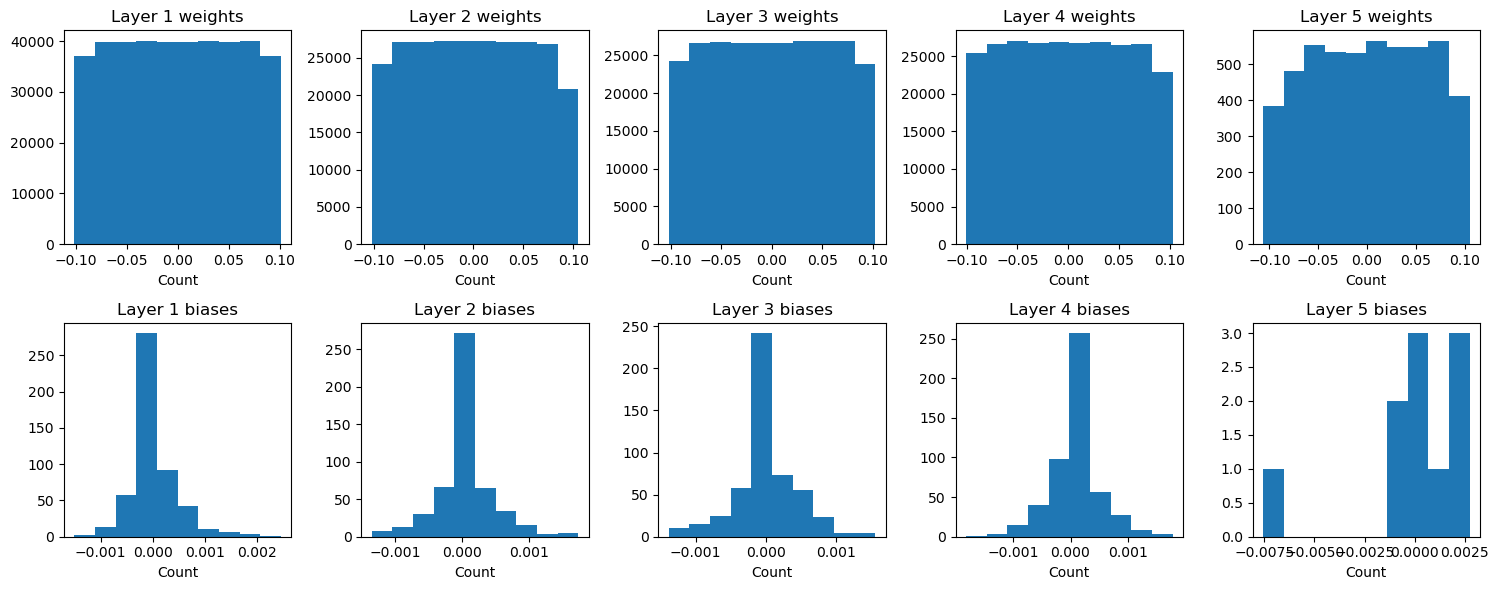

In [31]:
fig, axes = plt.subplots(2, len(model.layers), figsize=(3 * len(model.layers), 6))

for i, layer in enumerate(model.layers):

    axes[0, i].hist(layer.weights.flatten())
    axes[0, i].set_title(f"Layer {i+1} weights")
    axes[0, i].set_xlabel("Parameter value")
    axes[0, i].set_xlabel("Count")

    axes[1, i].hist(layer.biases.flatten())
    axes[1, i].set_title(f"Layer {i+1} biases")
    axes[1, i].set_xlabel("Parameter value")
    axes[1, i].set_xlabel("Count")

plt.tight_layout()
plt.savefig(os.path.join(figs_dir, f"NN_param_hist_{model_signature}.png"))
plt.show()

#### Store the trained model 

In [39]:
model_path = os.path.join(model_dir, f"NN_classifier_{model_signature}.pkl")
with open(model_path, "wb") as f: pickle.dump(model, f)

Store results

In [40]:
# Load results library, if it already exists
results_lib_path = os.path.join("results", "results.pkl")
if os.path.exists(results_lib_path): 
    with open(results_lib_path, "rb") as f: 
        results_library = pickle.load(f)
else: 
    results_library = []

# Add best model and combined results along with model details
model_result = {
    "model_signature":model_signature, 
    "best_test_accuracy":best_result["accuracy_test"],
    "best_train_accuracy":best_result["accuracy_train"],
    "best_total_accuracy":best_result["accuracy_all"], 
    "mean_test_accuracy":np.mean([r["accuracy_test"] for r in results]), 
    "mean_train_accuracy":np.mean([r["accuracy_train"] for r in results]), 
    "mean_total_accuracy":np.mean([r["accuracy_all"] for r in results]), 
    "learning_rate":learning_rate, 
    "batch_size":batch_size, 
    "weight_decay":weight_decay, 
    "epochs":epochs, 
    "layer_sizes":", ".join(str(layer.shape) for layer in model.layers),
    "depth":len(model.layers), 
    "num_params":sum([layer.weights.size + layer.biases.size for layer in model.layers]),
    "model_path": model_path, 
    "target_len": target_len
}

# Add results for each fold
for i, result in enumerate(results):  
    model_result[f"fold_{i}_train_accuracy"] = result["accuracy_test"]
    model_result[f"fold_{i}_test_accuracy"] = result["accuracy_train"]
    model_result[f"fold_{i}_total_accuracy"] = result["accuracy_all"]

results_library.append(model_result)

# Store results library
with open(results_lib_path, "wb") as f: 
    pickle.dump(results_library, f)

In [41]:
kfold_result_path = os.path.join(results_dir, f"{model_signature}_kfold.pkl")
with open(kfold_result_path, "wb") as f: 
    pickle.dump(results, f)

___

## Combining the preprocessing pipeline and NN classifier to a single function

In [42]:
def classify(samples: List[NDArray|pd.DataFrame], predict: Callable, preprocess: Callable) -> NDArray: 

    # Preprocess the samples
    X = preprocess(samples)
    
    # Predict the classes of the samples
    return predict(X)

In [43]:
from NN_preprocessing import NN_preprocess_samples

# Select random test set (NOTE: this is from the entire dataset)
index = np.random.choice(len(samples), 100).astype(int)
test_datas, test_labels = [samples[i] for i in index], [labels[i] for i in index]

preprocess = lambda s : NN_preprocess_samples(s, target_len=256)

# Predict the test set using the classify-function
predicted_labels = classify(test_datas, model.predict, NN_preprocess_samples)

# Measure prediction accuracy
print(f"Classification accuracy: {accuracy_score(test_labels, predicted_labels)*100:.0f} %")

Classification accuracy: 57 %
